In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.datasets import 
import torch.nn.functional as F
import optuna
import warnings


warnings.filterwarnings("ignore")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{device.type.upper()}")

-> Computação acelerada operando em: CUDA


In [ ]:
def load_and_preprocess_data(filepath, seq_length=14):
    df = pd.read_csv(filepath, parse_dates=['date'])
    df.set_index('date', inplace=True)
    df = df.sort_index()
    df = df.loc['2017-01-01':'2023-12-31']

    data = df[['close']].values

    train_size = int(len(data) * 0.8)
    train_data = data[:train_size]
    test_data  = data[train_size:]

    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled  = scaler.transform(test_data)

    def create_sequences(X, y, seq_length):
        xs, ys = [], []
        for i in range(len(X) - seq_length):
            xs.append(X[i:(i + seq_length)])
            ys.append(y[i + seq_length])
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(train_scaled, train_scaled, seq_length)
    X_test,  y_test  = create_sequences(test_scaled,  test_scaled,  seq_length)

    return X_train, y_train, X_test, y_test, scaler

In [ ]:


class AudioProcessingLSTM(nn.Module):
    """
    Estrutura adaptativa permitindo otimização de matrizes. Rege os parâmetros
    em arquitetura modular similar a implementações base de Convolutional Neural Networks
    enquanto emprega os portões intrínsecos de LSTM em empilhamento de camadas.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout_rate):
        super(AudioProcessingLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Camada recorrente processando a dependência do estado a longo e curto prazo
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            # Dropout inserido inter-camadas caso seja uma arquitetura mais profunda (stacked)
            dropout=dropout_rate if num_layers > 1 else 0.0
        )

        # Módulos de filtragem de sinal contra memorização dos pesos
        self.dropout = nn.Dropout(dropout_rate)
        
        # Cabeça densa de aproximação regressiva com afunilamento geométrico
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        # A inicialização zero padronizada do hidden e cell state em PyTorch (h_0, c_0)
        lstm_out, _ = self.lstm(x)

        # O fatiamento captura especificamente a representação encapsulada do
        # último passo dimensional gerado dentro do fluxo multivariado da sequência da matriz
        out = lstm_out[:, -1, :]

        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


In [ ]:

def execute_model_training_cycle(params, X_train, y_train, X_test, y_test, target_scaler, device):
    train_dataset = BitcoinSequenceDataset(X_train, y_train)
    test_dataset = BitcoinSequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)

    model = AudioProcessingLSTM(
        input_dim=X_train.shape[2],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout']
    ).to(device)

    criterion = directional_loss
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )

    epochs = 100
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 8

    # ── loop de treino com early stopping ──────────────────────────────────
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                epoch_val_loss += criterion(outputs, batch_y).item() * batch_X.size(0)
        epoch_val_loss /= len(test_loader.dataset)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # ── avaliação final — coleta predições e métricas ──────────────────────
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)

            val_loss += criterion(outputs, batch_y).item() * batch_X.size(0)
            all_preds.extend(outputs.cpu().numpy())
            all_trues.extend(batch_y.cpu().numpy())

    val_loss /= len(test_loader.dataset)

    preds_inverse = target_scaler.inverse_transform(all_preds)
    trues_inverse = target_scaler.inverse_transform(all_trues)

    pocid = calculate_pocid(trues_inverse, preds_inverse)
    rmse = np.sqrt(mean_squared_error(trues_inverse, preds_inverse))

    return val_loss, rmse, pocid, model, preds_inverse, trues_inverse

def optuna_objective(trial):
    """
    Espaço de busca reformulado para alinhar CV com desempenho real no teste.
    Foco: reduzir gap entre POCID cruzado e POCID final.
    """
    seq_length = trial.suggest_categorical('seq_length', [14, 30, 45, 60, 90])

    params = {
        'hidden_dim':   trial.suggest_int('hidden_dim', 64, 256, step=32),
        'num_layers':   trial.suggest_int('num_layers', 1, 2),
        'dropout':      trial.suggest_float('dropout', 0.1, 0.35),
        'lr':           trial.suggest_float('lr', 5e-4, 5e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        'batch_size':   trial.suggest_categorical('batch_size', [32, 64])
    }

    X_train_full, y_train_full, _, _, target_scaler = load_and_preprocess_data(
        'data-bitcoin_timedata-2023_v2.csv',
        seq_length=seq_length
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tscv = TimeSeriesSplit(n_splits=5)
    cv_pocids = []

    for train_index, val_index in tscv.split(X_train_full):
        X_fold_train, X_fold_val = X_train_full[train_index], X_train_full[val_index]
        y_fold_train, y_fold_val = y_train_full[train_index], y_train_full[val_index]

        if len(X_fold_train) < 10 or len(X_fold_val) < 10:
            continue

        _, _, fold_pocid, _, _, _ = execute_model_training_cycle(
            params, X_fold_train, y_fold_train, X_fold_val, y_fold_val, target_scaler, device
        )
        cv_pocids.append(fold_pocid)

    if not cv_pocids:
        return 0.0

    # Penaliza alta variância entre folds — prefere estabilidade a pico isolado
    mean_pocid = np.mean(cv_pocids)
    std_pocid  = np.std(cv_pocids)
    return mean_pocid - 0.5 * std_pocid

[I 2026-05-01 13:08:19,041] A new study created in memory with name: no-name-0647c1f9-dbd1-4f3a-bd19-4959b1080712


 Inicializando Otimização Bayesiana Estruturada do Espaço LSTM em Pytorch...


[I 2026-05-01 13:08:47,101] Trial 0 finished with value: 44.342648720807944 and parameters: {'seq_length': 30, 'hidden_dim': 96, 'num_layers': 1, 'dropout': 0.31654403644373375, 'lr': 0.0019956529392808394, 'weight_decay': 0.000133112160807369, 'batch_size': 64}. Best is trial 0 with value: 44.342648720807944.
[I 2026-05-01 13:08:57,541] Trial 1 finished with value: 44.85605328819723 and parameters: {'seq_length': 14, 'hidden_dim': 160, 'num_layers': 1, 'dropout': 0.17280728504951048, 'lr': 0.002045610287221893, 'weight_decay': 2.62108787826544e-06, 'batch_size': 64}. Best is trial 1 with value: 44.85605328819723.
[I 2026-05-01 13:09:22,529] Trial 2 finished with value: 45.815191177068414 and parameters: {'seq_length': 30, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.1426310309218229, 'lr': 0.0005807932994623225, 'weight_decay': 0.0007025166339242157, 'batch_size': 32}. Best is trial 2 with value: 45.815191177068414.
[I 2026-05-01 13:09:43,800] Trial 3 finished with value: 44.877851



-> Máximo POCID Cruzado Alcançado: 47.53%
   * seq_length: 60
   * hidden_dim: 160
   * num_layers: 2
   * dropout: 0.21029073810595508
   * lr: 0.000578824811001753
   * weight_decay: 9.103102840199448e-05
   * batch_size: 64




-> Root Mean Squared Error (RMSE) Absoluto: $1028.55
-> Métrica Qualitativa Financeira (POCID): 45.33% de Correção Direcional (Tendência)


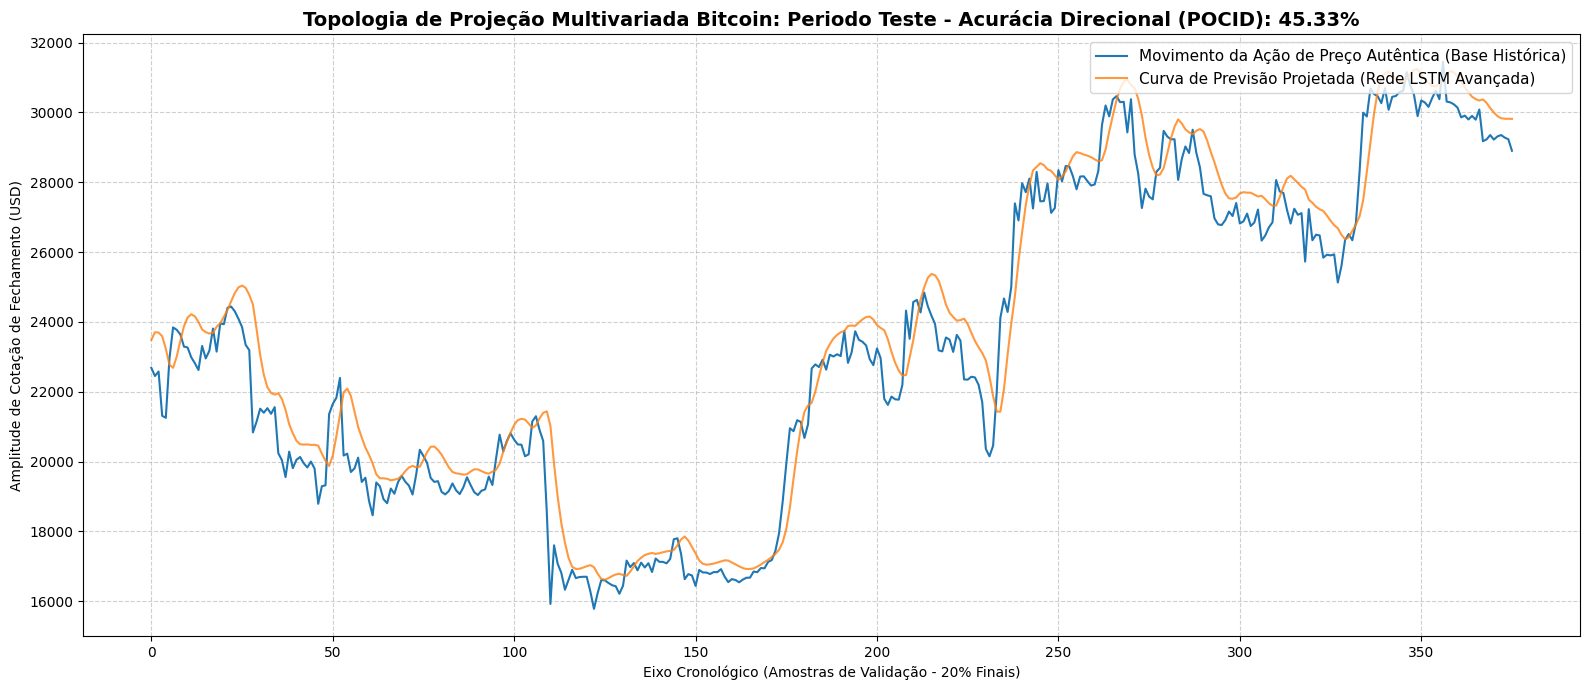

[FIM] Ciclo de otimização algorítmica finalizado com segurança metodológica.


In [14]:
# =============================================================================
# 5. BLOCO DE CONTROLE CENTRAL (SCRIPT MAIN)
# =============================================================================
if __name__ == "__main__":
    print(" Inicializando Otimização Bayesiana Estruturada do Espaço LSTM em Pytorch...")

    # Mude direction='minimize' para direction='maximize'
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

    # Pode manter o n_trials=100 ou mais
    study.optimize(optuna_objective, n_trials=200)

    print("\n")
    print(f"-> Máximo POCID Cruzado Alcançado: {study.best_value:.2f}%")

    best_params = study.best_params
    for key, value in best_params.items():
        print(f"   * {key}: {value}")

    print("\n")

    best_seq_length = best_params.pop('seq_length')
    X_train, y_train, X_test, y_test, target_scaler = load_and_preprocess_data(
        'data-bitcoin_timedata-2023_v2.csv',
        seq_length=best_seq_length
    )

    final_loss, final_rmse, final_pocid, final_model, preds, trues = execute_model_training_cycle(
        best_params, X_train, y_train, X_test, y_test, target_scaler, device
    )

    print("\n")
    print(f"-> Root Mean Squared Error (RMSE) Absoluto: ${final_rmse:.2f}")
    print(f"-> Métrica Qualitativa Financeira (POCID): {final_pocid:.2f}% de Correção Direcional (Tendência)")

    # Exposição Gráfica Qualitativa das Conclusões Modeladas
    plt.figure(figsize=(16, 7))
    plt.plot(trues, label='Movimento da Ação de Preço Autêntica (Base Histórica)', color='#1f77b4', linewidth=1.5)
    plt.plot(preds, label='Curva de Previsão Projetada (Rede LSTM Avançada)', color='#ff7f0e', alpha=0.8, linewidth=1.5)
    plt.title(f'Topologia de Projeção Multivariada Bitcoin: Periodo Teste - Acurácia Direcional (POCID): {final_pocid:.2f}%', fontsize=14, fontweight='bold')
    plt.xlabel('Eixo Cronológico (Amostras de Validação - 20% Finais)')
    plt.ylabel('Amplitude de Cotação de Fechamento (USD)')
    plt.legend(loc='upper right', frameon=True, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print("[FIM] Ciclo de otimização algorítmica finalizado com segurança metodológica.")

In [15]:
import optuna.visualization as vis
# flllanç000010u
vis.plot_param_importances(study).show()

vis.plot_optimization_history(study).show()

vis.plot_parallel_coordinate(study).show()